In [1]:
import os
import sys
from pathlib import Path

library_path = os.path.abspath('../../src')
if library_path not in sys.path:
    sys.path.append(library_path)
library_path = Path(library_path)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

DATA_PATH = library_path.parent / "data"
PLOTS_PATH = library_path.parent / "plots"
PLOTS_PATH.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

In [3]:
df = pd.read_csv(DATA_PATH / "wrangled_data.csv", low_memory=False)

print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"\nDatasets:")
print(df["dataset"].value_counts())

Shape: 38,995 rows x 44 columns

Datasets:
dataset
HSE 2019        8201
HSE 2018        8177
HSE 2017        7996
HSE 2022        7727
DAPHNIE 2024    5237
DAPHNIE 2023    1657
Name: count, dtype: int64


## Within-HSE Consistency Check: Pre-2020 vs Post-2020

### Rationale

Before pooling the four HSE waves as a single target distribution for the covariate shift
analysis, we need to verify that they are internally consistent. The HSE data span 2017–2022,
with a natural break around COVID-19:

- **Pre-2020:** HSE 2017, 2018, 2019 (combined n ≈ 24,379)
- **Post-2020:** HSE 2022 (n ≈ 7,729)

If the pre- and post-2020 waves differ substantially on key covariates, pooling them as a
single "HSE target" would conflate **real secular change** (pandemic effects on employment,
health behaviour, BMI, mental health) with the sampling-frame differences we are trying to
measure. We need to know this before treating the full HSE pool as a stable reference.

The question is not whether any difference exists — some drift is expected over five years —
but whether differences are large enough to matter for norm derivation. The same SMD
threshold ($|\text{SMD}| > 0.1$) applies.

### SMD convention

$$\text{SMD} = \frac{\bar{x}_{\text{post-2020}} - \bar{x}_{\text{pre-2020}}}
{\sqrt{(s^2_{\text{post-2020}} + s^2_{\text{pre-2020}}) / 2}}$$

Positive SMD means the post-2020 (HSE 2022) value is higher. Both groups use `wt_int`
as survey weights.

In [ ]:
# Restrict to HSE rows; exclude identifiers, weights, outcome variables, and redundant covariates
# age3cat dropped in favour of age7cat (finer granularity, strictly more informative)
EXCLUDE = {"dataset", "wt_int", "svy_wt", "SurveyWeight", "EQ_index",
           "util_rowen", "EQvas", "LSS", "LSS_rs", "age3cat"}

hse_all = df[df["dataset"].str.startswith("HSE")].copy()
analytic_cols = [c for c in hse_all.columns
                 if c not in EXCLUDE and pd.api.types.is_numeric_dtype(hse_all[c])]

print(f"HSE rows: {len(hse_all):,}")
print(f"
Waves:")
print(hse_all["dataset"].value_counts().sort_index())
print(f"
Analytic columns ({len(analytic_cols)}):")
print(analytic_cols)

In [6]:
def weighted_mean(series, weights):
    mask = series.notna() & weights.notna() & (weights > 0)
    if mask.sum() == 0:
        return np.nan
    s, w = series[mask], weights[mask]
    return np.average(s, weights=w)


def weighted_var(series, weights):
    mask = series.notna() & weights.notna() & (weights > 0)
    if mask.sum() < 2:
        return np.nan
    s, w = series[mask], weights[mask]
    mu = np.average(s, weights=w)
    return np.average((s - mu) ** 2, weights=w)


def compute_smd(source_series, source_weights, target_series, target_weights):
    """Compute SMD between source (DAPHNIE) and target (HSE), both weighted."""
    mu_s = weighted_mean(source_series, source_weights)
    mu_t = weighted_mean(target_series, target_weights)
    if np.isnan(mu_s) or np.isnan(mu_t):
        return np.nan
    var_s = weighted_var(source_series, source_weights)
    var_t = weighted_var(target_series, target_weights)
    if np.isnan(var_s) or np.isnan(var_t):
        return np.nan
    pooled_sd = np.sqrt((var_s + var_t) / 2)
    if pooled_sd == 0:
        return np.nan
    return (mu_s - mu_t) / pooled_sd

In [ ]:
# Split datasets
pre = hse_all[hse_all["dataset"].isin(["HSE 2017", "HSE 2018", "HSE 2019"])].copy()

post = hse_all[hse_all["dataset"] == "HSE 2022"].copy()

# Weights
pre_weights = pre["wt_int"].fillna(1.0)
post_weights = post["wt_int"].fillna(1.0)

# Sample sizes
print(f"Pre-2020 (2017–2019): n = {len(pre):,}")
print(f"Post-2020 (2022):     n = {len(post):,}")

# Compute SMDs
smds = {}

for col in analytic_cols:
    smds[col] = compute_smd(
        post[col], post_weights,   # source = post-2020
        pre[col], pre_weights      # target = pre-2020
    )

# Create sorted Series
smd_pre_post = (
    pd.Series(smds, name="SMD (post − pre)")
    .sort_values(key=abs, ascending=False)
)

# Output
print(
    "\nSMD table (positive = higher in HSE 2022 than pre-2020):"
)

display(smd_pre_post.round(3).to_frame())

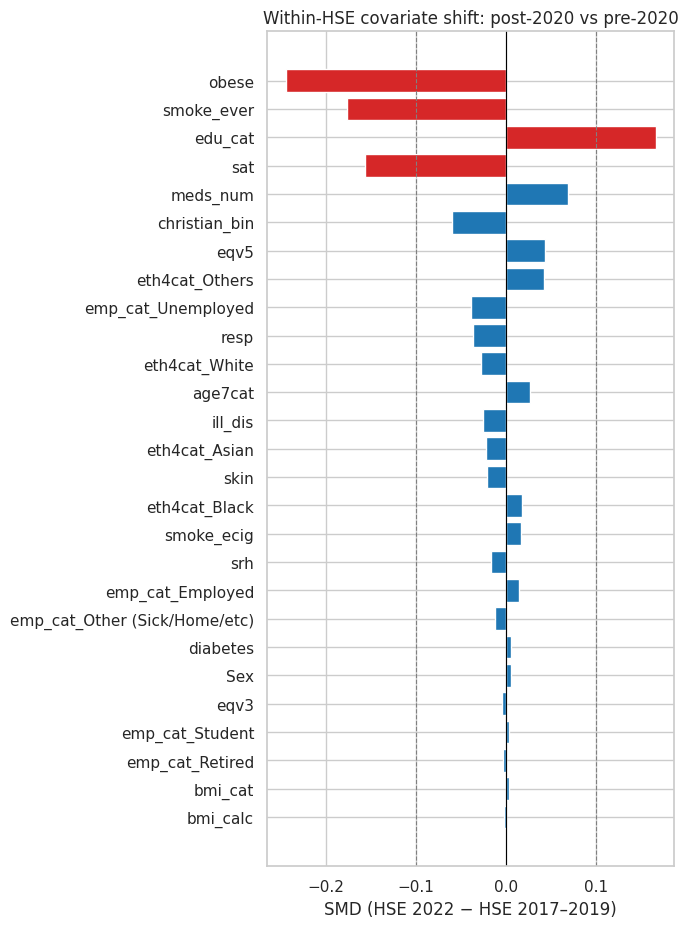

In [8]:
smds_plot = smd_pre_post.dropna().sort_values(key=abs)
colors = ["#d62728" if abs(v) > 0.1 else "#1f77b4" for v in smds_plot]

fig, ax = plt.subplots(figsize=(7, max(5, len(smds_plot) * 0.35)))
ax.barh(smds_plot.index, smds_plot.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.axvline(0.1, color="grey", linewidth=0.8, linestyle="--")
ax.axvline(-0.1, color="grey", linewidth=0.8, linestyle="--")
ax.set_xlabel("SMD (HSE 2022 − HSE 2017–2019)")
ax.set_title("Within-HSE covariate shift: post-2020 vs pre-2020")
plt.tight_layout()
plt.savefig(PLOTS_PATH / "love_plot_hse_pre_post.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
valid = smd_pre_post.dropna()
imbalanced = valid[valid.abs() > 0.1].sort_values(key=abs, ascending=False)

print(f"Variables with |SMD| > 0.1: {len(imbalanced)} / {len(valid)}")
print()
print("These variables show meaningful pre/post-2020 drift within HSE.")
print("If any are key covariates in the density ratio model, pooling HSE waves")
print("without adjustment may bias the importance weights.\n")
display(imbalanced.round(3).to_frame())

Variables with |SMD| > 0.1: 4 / 27

These variables show meaningful pre/post-2020 drift within HSE.
If any are key covariates in the density ratio model, pooling HSE waves
without adjustment may bias the importance weights.



,SMD (post − pre)
obese,-0.244
smoke_ever,-0.176
edu_cat,0.166
sat,-0.156
